# 01 - Exploratory Data Analysis (Phishing Classification)

This notebook performs a professional, reproducible Exploratory Data Analysis (EDA) on the phishing dataset. It covers: data ingestion, overview, cleaning checks, feature summaries, visualizations, correlation analysis, outlier detection, and recommended next steps for modeling.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.options.display.max_columns = 200


In [23]:
df = pd.read_csv('../data/raw/phishing_features.csv')
print("Data oaded Successfully")

Data oaded Successfully


## Dropping Unnecessary Column

The `drop()` function removes the **'url'** column from the dataset, as it is not required for further analysis or model building. This helps simplify the dataset and reduces unnecessary features.

In [ ]:
df.drop('url',axis=1,inplace=True)

# Dataset Preview
The following code displays the first and last few rows of the dataset, along with its dimensions and column names, providing a quick overview of the data structure and available features.

In [25]:
# Quick preview
display(df.head(5))
display(df.tail(3))
print('\nShape:', df.shape)
print('\nColumns:', list(df.columns))

,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
160061,safeexample98.net,0,17,1,0,0,0,0,0,NaN,0,2,3.499228
160062,safeexample99.net,0,17,1,0,0,0,0,0,NaN,0,2,3.381580
160063,safeexample100.net,0,18,1,0,0,0,0,0,NaN,0,3,3.503258



Shape: (160064, 13)

Columns: ['url', 'label', 'url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'tld', 'special_char_count', 'digits_count', 'entropy']


## Dataframe information & types
Check data types, non-null counts and memory usage to understand column types and potential casts.

In [26]:
df.info()
display(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160064 entries, 0 to 160063
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 160064 non-null  object 
 1   label               160064 non-null  int64  
 2   url_length          160064 non-null  int64  
 3   num_dots            160064 non-null  int64  
 4   has_https           160064 non-null  int64  
 5   has_ip              160064 non-null  int64  
 6   num_subdirs         160064 non-null  int64  
 7   num_params          160064 non-null  int64  
 8   suspicious_words    160064 non-null  int64  
 9   tld                 159243 non-null  object 
 10  special_char_count  160064 non-null  int64  
 11  digits_count        160064 non-null  int64  
 12  entropy             160064 non-null  float64
dtypes: float64(1), int64(10), object(2)
memory usage: 15.9+ MB


int64      10
object      2
float64     1
Name: count, dtype: int64

# Descriptive Statistics

The `df.describe()` function generates summary statistics for numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values, providing a quick overview of the dataset's distribution.

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,160064.0,0.994877,0.071391,0.000000,1.000000,1.000000,1.00000,1.000000
url_length,160064.0,55.107382,101.782469,6.000000,30.000000,37.000000,65.00000,25523.000000
num_dots,160064.0,2.998963,1.119210,1.000000,2.000000,3.000000,4.00000,59.000000
has_https,160064.0,0.434089,0.495638,0.000000,0.000000,0.000000,1.00000,1.000000
has_ip,160064.0,0.485475,0.499791,0.000000,0.000000,0.000000,1.00000,1.000000
num_subdirs,160064.0,4.128436,2.090180,0.000000,3.000000,3.000000,4.00000,104.000000
num_params,160064.0,0.221499,0.935608,0.000000,0.000000,0.000000,0.00000,45.000000
suspicious_words,160064.0,0.023809,0.168235,0.000000,0.000000,0.000000,0.00000,3.000000
special_char_count,160064.0,1.495446,3.699627,0.000000,0.000000,0.000000,1.00000,264.000000
digits_count,160064.0,12.737036,17.420579,0.000000,3.000000,12.000000,16.00000,3413.000000


## Missing values and duplicates
Assess data quality: missingness and duplicate rows.

In [28]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if missing.empty:
	print('No missing values detected.')
else:
	display(missing)


# Duplicates
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

tld    821
dtype: int64

Duplicate rows: 0


## Identify candidate target column
Attempt to identify the label/target column commonly used in classification tasks.

In [29]:
# Heuristic: look for likely target names and binary columns
possible_targets = [c for c in df.columns if c.lower() in {'target','label','class','result','status','is_phishing','phishing'}]
binary_cols = [c for c in df.columns if df[c].nunique() == 2]
print('Possible target columns (by name):', possible_targets)
print('Binary columns (nunique==2):', binary_cols)

# If a single obvious target exists, set `target_col`. Otherwise leave None for manual selection.
target_col = possible_targets[0] if len(possible_targets) == 1 else None
print('Selected target_col =', target_col)

Possible target columns (by name): ['label']
Binary columns (nunique==2): ['label', 'has_https', 'has_ip']
Selected target_col = label


## Basic statistics and class balance
If a `target_col` was identified, show class balance and a brief class report.

label
1    159244
0       820
Name: count, dtype: int64

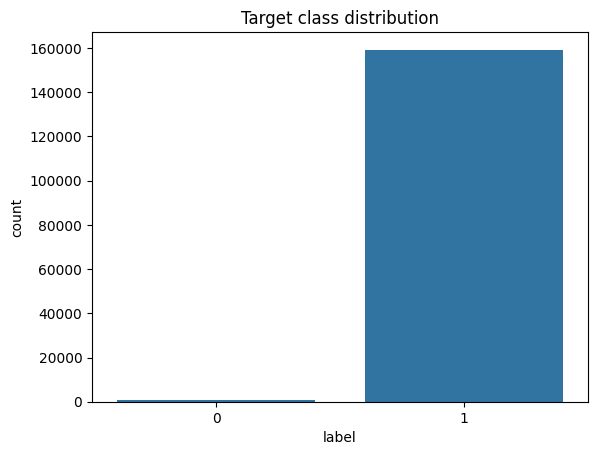

In [30]:
if target_col:
	display(df[target_col].value_counts(dropna=False))
	sns.countplot(x=target_col, data=df)
	plt.title('Target class distribution')
	plt.show()
else:
	print('No automatic target column selected. Use the list above to pick one (e.g., set target_col = "column_name").')

## Numerical vs Categorical features
Separate columns by dtype for tailored visualizations.

In [32]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numerical columns:', num_cols)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()[1]
print('Categorical columns:', cat_cols)


Numerical columns: ['label', 'url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'special_char_count', 'digits_count', 'entropy']
Categorical columns: tld


## Correlation matrix (numerical features)
Visualize pairwise correlations to identify strongly related features.

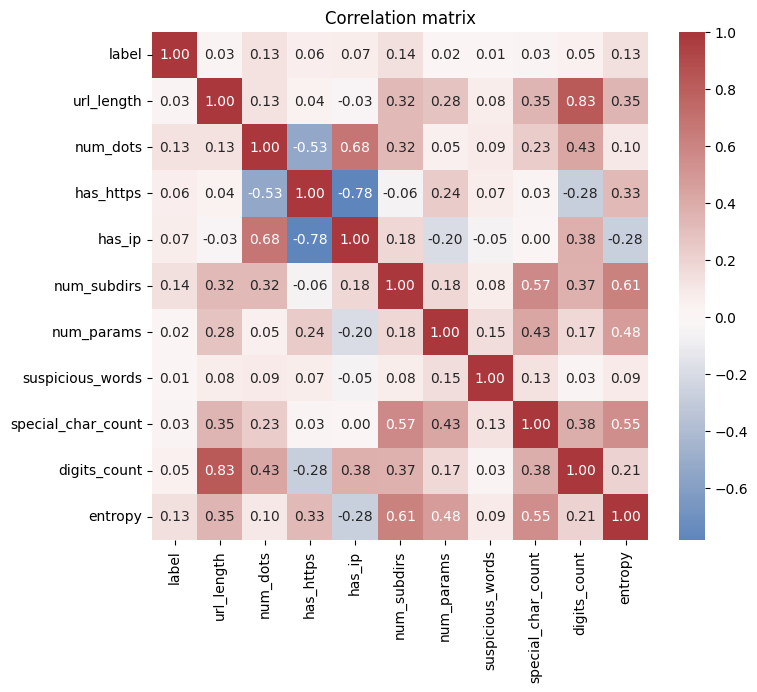

In [33]:
if len(num_cols) >= 2:
	corr = df[num_cols[:20]].corr()
	plt.figure(figsize=(max(8, len(num_cols)*0.6), max(6, len(num_cols)*0.6)))
	sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
	plt.title('Correlation matrix')
	plt.show()
else:
	print('Not enough numerical columns for correlation matrix.')

## Distribution plots and outlier inspection (numerical)
Show histograms and boxplots for each numerical column to inspect distributions and outliers.

## Simple outlier detection (IQR method)
Flag records with extreme values per numeric column using the IQR rule.

In [34]:
outlier_flags = pd.DataFrame(index=df.index)
for c in num_cols:
	Q1 = df[c].quantile(0.25)
	Q3 = df[c].quantile(0.75)
	IQR = Q3 - Q1
	lower = Q1 - 1.5 * IQR
	upper = Q3 + 1.5 * IQR
	outlier_flags[c + '_outlier'] = ((df[c] < lower) | (df[c] > upper))

outlier_counts = outlier_flags.sum().sort_values(ascending=False)
display(outlier_counts[outlier_counts>0].head(10))

num_subdirs_outlier           30597
special_char_count_outlier    25339
num_params_outlier            15826
url_length_outlier            12907
digits_count_outlier           7199
entropy_outlier                6375
suspicious_words_outlier       3414
label_outlier                   820
num_dots_outlier                331
dtype: int64

## Boxplot Visualization for Numerical Features

The following code creates horizontal boxplots for all numerical columns using subplots. This visualization helps identify the distribution of each feature and detect potential outliers in a clean and organized layout.

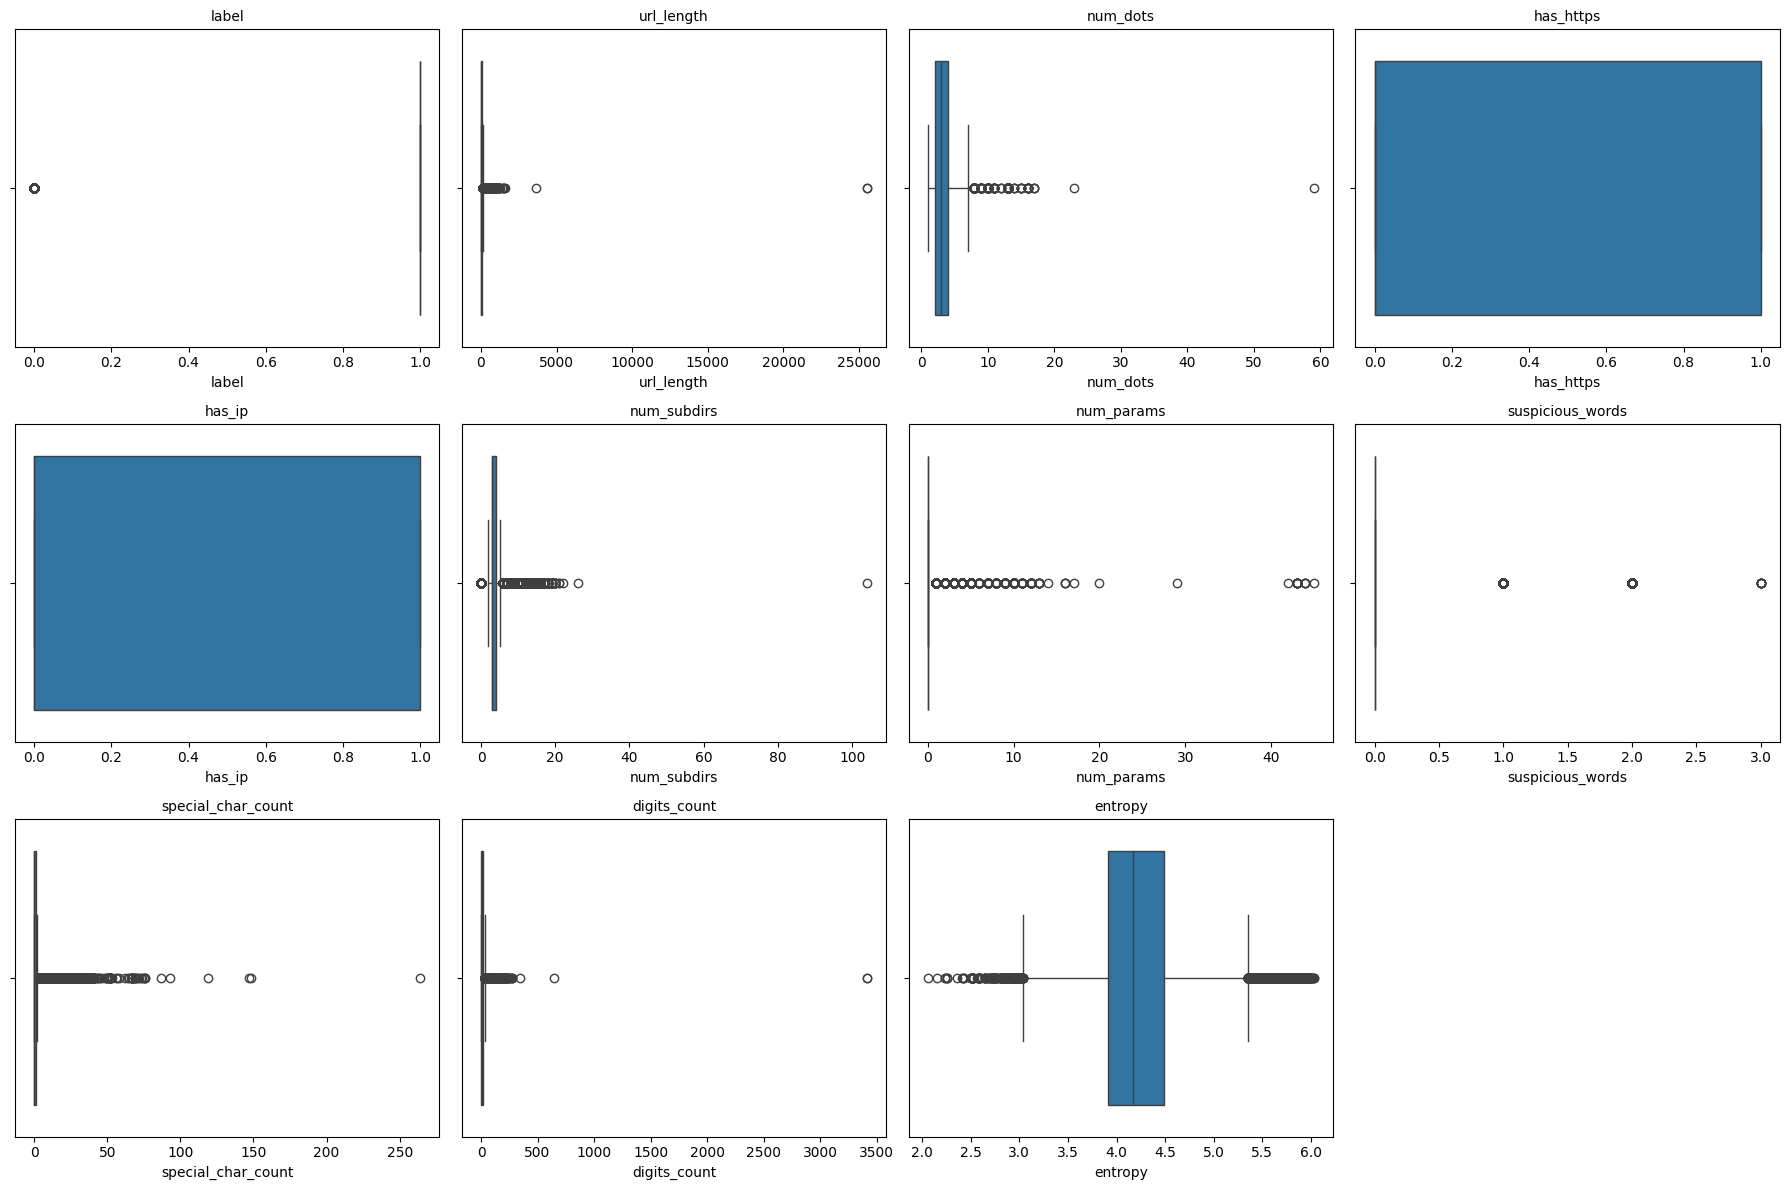

In [35]:
n_cols = 4   # 4 plots per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])   # Horizontal boxplot
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Bar Chart for Top Categories

The following code visualizes the top 20 most frequent values in the categorical column using a bar chart. Displaying only the most common categories improves readability and highlights the dominant categories in the dataset.

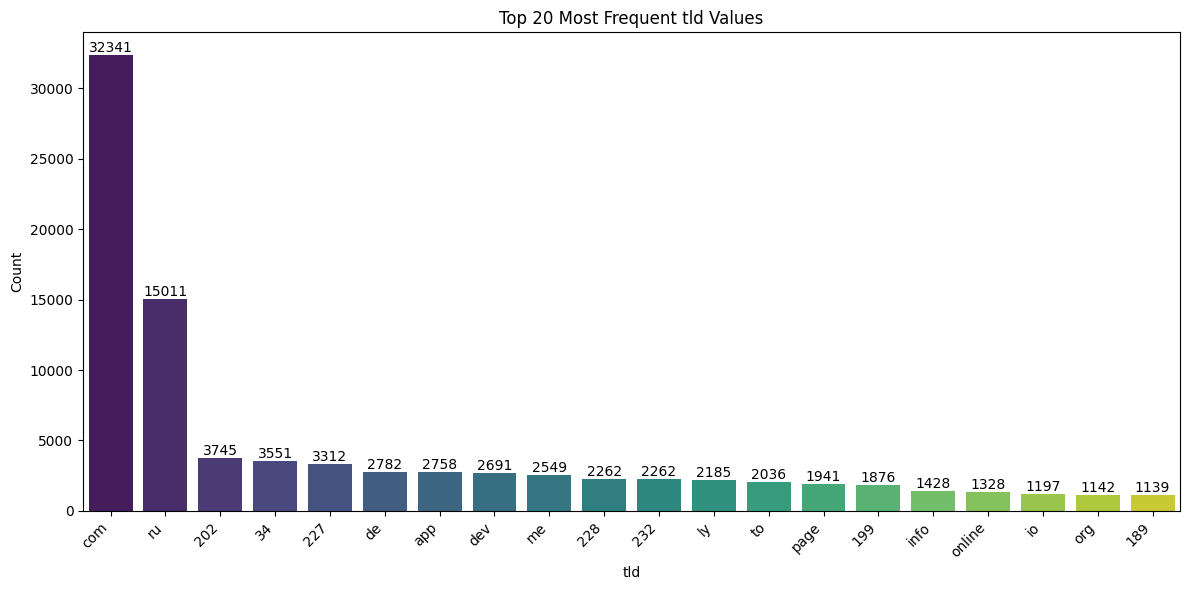

In [36]:
top_n = 20
top_categories = df[cat_cols].value_counts().head(top_n)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_categories.index,
    y=top_categories.values,
    palette='viridis'
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Top {top_n} Most Frequent {cat_cols} Values')
plt.xlabel(cat_cols)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary & recommended next steps
- Documented data quality checks: missing values, duplicates and outliers found above.
- If a target column wasn't detected automatically, pick and set `label` for supervised modeling.
- Feature engineering: create features from URLs/domains (if present), tokenization for text, and aggregation for numerical skew handling.
- Modeling notes: consider stratified sampling for imbalanced targets, baseline with logistic regression, and tree-based models for feature importance.

Next: finalize `lablel`, perform cleaning/encoding, and implement a reproducible training pipeline in `src/train.py`.